# 🚢 PHÂN TÍCH DỮ LIỆU TITANIC - EDA CHI TIẾT

## 🎯 Mục tiêu
- Phân tích toàn diện dữ liệu Titanic từ Kaggle
- Tìm hiểu mối quan hệ giữa các features và biến mục tiêu (Survived)
- Đánh giá chất lượng dữ liệu và xử lý missing values
- Chuẩn bị dữ liệu cho mô hình machine learning
- Đưa ra insights và đề xuất cải tiến mô hình

## 📋 Cấu trúc notebook
1. **📊 Tổng quan dữ liệu** - Hiểu về dataset và thông tin cơ bản
2. **🔍 Phân tích missing values** - Đánh giá chất lượng dữ liệu
3. **📈 Phân tích từng feature** - EDA chi tiết cho từng biến
4. **🔗 Phân tích mối quan hệ** - Tương quan giữa các biến
5. **🛠️ Feature Engineering** - Tạo features mới
6. **📊 Kết luận và đề xuất** - Tổng hợp insights


# 1. 📊 TỔNG QUAN DỮ LIỆU

## 1.1 Import thư viện cần thiết


In [ ]:
# Import các thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import chi2_contingency
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Cấu hình hiển thị
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Cấu hình pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("✅ Đã import thành công tất cả thư viện cần thiết")


## 1.2 Load dữ liệu


In [ ]:
# Load dữ liệu
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print("📊 THÔNG TIN CƠ BẢN VỀ DATASET")
print("=" * 50)
print(f"Kích thước tập train: {train_df.shape}")
print(f"Kích thước tập test: {test_df.shape}")
print(f"Tổng số hành khách: {train_df.shape[0] + test_df.shape[0]}")
print(f"Số features: {train_df.shape[1] - 1}")  # Trừ đi cột Survived

print("\n📋 CÁC CỘT TRONG DATASET:")
print("=" * 30)
for i, col in enumerate(train_df.columns, 1):
    print(f"{i:2d}. {col}")

print("\n🎯 TARGET VARIABLE:")
print("=" * 20)
print(f"Survived: {train_df['Survived'].value_counts().to_dict()}")
print(f"Tỷ lệ sống sót: {train_df['Survived'].mean():.2%}")


## 1.3 Xem mẫu dữ liệu


In [ ]:
# Hiển thị mẫu dữ liệu
print("🔍 MẪU DỮ LIỆU TRAIN (5 hàng đầu):")
print("=" * 40)
display(train_df.head())

print("\n🔍 MẪU DỮ LIỆU TEST (5 hàng đầu):")
print("=" * 40)
display(test_df.head())

print("\n📊 THÔNG TIN THỐNG KÊ CƠ BẢN:")
print("=" * 35)
display(train_df.describe(include='all'))


# 2. 🔍 PHÂN TÍCH MISSING VALUES

## 2.1 Kiểm tra missing values trong từng dataset


In [ ]:
# Hàm kiểm tra missing values
def analyze_missing_values(df, dataset_name):
    print(f"🔍 PHÂN TÍCH MISSING VALUES - {dataset_name.upper()}")
    print("=" * 50)
    
    missing_data = df.isnull().sum()
    missing_percent = (missing_data / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Cột': missing_data.index,
        'Số lượng missing': missing_data.values,
        'Phần trăm missing': missing_percent.values
    })
    
    missing_df = missing_df[missing_df['Số lượng missing'] > 0].sort_values('Số lượng missing', ascending=False)
    
    if len(missing_df) > 0:
        print("❌ CÁC CỘT CÓ MISSING VALUES:")
        display(missing_df)
        
        # Vẽ biểu đồ missing values
        plt.figure(figsize=(12, 6))
        bars = plt.bar(missing_df['Cột'], missing_df['Phần trăm missing'], color='coral')
        plt.title(f'Phần trăm Missing Values - {dataset_name}', fontsize=14, fontweight='bold')
        plt.xlabel('Các cột', fontsize=12)
        plt.ylabel('Phần trăm (%)', fontsize=12)
        plt.xticks(rotation=45)
        
        # Thêm giá trị trên các cột
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{height:.1f}%', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
    else:
        print("✅ Không có missing values!")
    
    return missing_df

# Phân tích missing values cho train và test
train_missing = analyze_missing_values(train_df, "Train")
test_missing = analyze_missing_values(test_df, "Test")


## 2.2 Phân tích chi tiết missing values theo từng cột


In [ ]:
# Phân tích chi tiết từng cột có missing values
print("🔍 PHÂN TÍCH CHI TIẾT MISSING VALUES")
print("=" * 45)

# 1. Age - Tuổi
print("\n1️⃣ PHÂN TÍCH CỘT AGE (Tuổi):")
print("-" * 30)
print(f"Missing values: {train_df['Age'].isnull().sum()} / {len(train_df)} ({train_df['Age'].isnull().sum()/len(train_df)*100:.1f}%)")

# Phân tích Age theo các nhóm khác nhau
print("\n📊 Phân tích Age theo giới tính và hạng vé:")
age_analysis = train_df.groupby(['Sex', 'Pclass'])['Age'].agg(['count', 'mean', 'median', 'std']).round(2)
display(age_analysis)

# Vẽ biểu đồ phân phối Age
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Biểu đồ 1: Phân phối Age theo Survived
train_df[train_df['Age'].notna()].boxplot(column='Age', by='Survived', ax=axes[0])
axes[0].set_title('Phân phối Age theo Survived')
axes[0].set_xlabel('Survived')
axes[0].set_ylabel('Age')

# Biểu đồ 2: Histogram Age
train_df['Age'].hist(bins=30, ax=axes[1], alpha=0.7, color='skyblue')
axes[1].set_title('Phân phối Age')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Tần suất')

plt.tight_layout()
plt.show()

print("\n💡 NHẬN XÉT VỀ AGE:")
print("- Age có 177 missing values (19.9%)")
print("- Cần impute dựa trên Sex và Pclass")
print("- Có sự khác biệt về tuổi trung bình giữa các nhóm")


In [ ]:
# 2. Cabin - Phòng cabin
print("\n2️⃣ PHÂN TÍCH CỘT CABIN (Phòng cabin):")
print("-" * 35)
print(f"Missing values: {train_df['Cabin'].isnull().sum()} / {len(train_df)} ({train_df['Cabin'].isnull().sum()/len(train_df)*100:.1f}%)")

# Phân tích Cabin
cabin_data = train_df['Cabin'].dropna()
print(f"\n📊 Thống kê Cabin:")
print(f"- Số cabin có dữ liệu: {len(cabin_data)}")
print(f"- Số cabin duy nhất: {cabin_data.nunique()}")

# Phân tích deck (chữ cái đầu của cabin)
cabin_data_clean = cabin_data.str[0].value_counts()
print(f"\n📋 Phân bố theo Deck (chữ cái đầu):")
display(cabin_data_clean)

# Vẽ biểu đồ phân bố deck
plt.figure(figsize=(10, 6))
cabin_data_clean.plot(kind='bar', color='lightcoral')
plt.title('Phân bố hành khách theo Deck', fontsize=14, fontweight='bold')
plt.xlabel('Deck', fontsize=12)
plt.ylabel('Số lượng hành khách', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n💡 NHẬN XÉT VỀ CABIN:")
print("- Cabin có 687 missing values (77.1%) - rất nhiều!")
print("- Có thể tạo feature Deck từ chữ cái đầu")
print("- Deck có thể liên quan đến vị trí và giá vé")


In [ ]:
# 3. Embarked - Cảng lên tàu
print("\n3️⃣ PHÂN TÍCH CỘT EMBARKED (Cảng lên tàu):")
print("-" * 40)
print(f"Missing values: {train_df['Embarked'].isnull().sum()} / {len(train_df)} ({train_df['Embarked'].isnull().sum()/len(train_df)*100:.1f}%)")

# Phân tích Embarked
embarked_counts = train_df['Embarked'].value_counts()
print(f"\n📊 Phân bố theo cảng lên tàu:")
display(embarked_counts)

# Phân tích Embarked vs Survived
embarked_survival = pd.crosstab(train_df['Embarked'], train_df['Survived'], margins=True)
embarked_survival_pct = pd.crosstab(train_df['Embarked'], train_df['Survived'], normalize='index') * 100
print(f"\n📈 Tỷ lệ sống sót theo cảng lên tàu:")
display(embarked_survival_pct.round(2))

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Biểu đồ 1: Số lượng theo Embarked
embarked_counts.plot(kind='bar', ax=axes[0], color='lightgreen')
axes[0].set_title('Số lượng hành khách theo cảng lên tàu')
axes[0].set_xlabel('Embarked')
axes[0].set_ylabel('Số lượng')
axes[0].tick_params(axis='x', rotation=0)

# Biểu đồ 2: Tỷ lệ sống sót theo Embarked
embarked_survival_pct.plot(kind='bar', ax=axes[1], color=['red', 'green'])
axes[1].set_title('Tỷ lệ sống sót theo cảng lên tàu')
axes[1].set_xlabel('Embarked')
axes[1].set_ylabel('Tỷ lệ (%)')
axes[1].legend(['Không sống sót', 'Sống sót'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("\n💡 NHẬN XÉT VỀ EMBARKED:")
print("- Chỉ có 2 missing values (0.2%)")
print("- Southampton (S) có nhiều hành khách nhất")
print("- Cherbourg (C) có tỷ lệ sống sót cao nhất")
print("- Có thể impute bằng 'S' (mode)")


# 3. 📈 PHÂN TÍCH TỪNG FEATURE

## 3.1 Phân tích Target Variable - Survived


In [ ]:
# Phân tích Target Variable - Survived
print("🎯 PHÂN TÍCH TARGET VARIABLE - SURVIVED")
print("=" * 45)

# Thống kê cơ bản
survived_counts = train_df['Survived'].value_counts()
survived_pct = train_df['Survived'].value_counts(normalize=True) * 100

print("📊 THỐNG KÊ CƠ BẢN:")
print(f"- Sống sót: {survived_counts[1]} người ({survived_pct[1]:.1f}%)")
print(f"- Không sống sót: {survived_counts[0]} người ({survived_pct[0]:.1f}%)")
print(f"- Tổng: {len(train_df)} người")

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Biểu đồ 1: Số lượng
survived_counts.plot(kind='bar', ax=axes[0], color=['red', 'green'])
axes[0].set_title('Số lượng hành khách theo tình trạng sống sót', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Survived (0: Không sống sót, 1: Sống sót)')
axes[0].set_ylabel('Số lượng')
axes[0].tick_params(axis='x', rotation=0)

# Thêm giá trị trên cột
for i, v in enumerate(survived_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

# Biểu đồ 2: Phần trăm
wedges, texts, autotexts = axes[1].pie(survived_counts.values, 
                                       labels=['Không sống sót', 'Sống sót'],
                                       autopct='%1.1f%%',
                                       colors=['red', 'green'],
                                       startangle=90)
axes[1].set_title('Tỷ lệ sống sót', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 NHẬN XÉT VỀ TARGET VARIABLE:")
print("- Dataset có sự mất cân bằng nhẹ (61.6% không sống sót vs 38.4% sống sót)")
print("- Cần chú ý đến class imbalance khi đánh giá mô hình")
print("- Có thể sử dụng stratified sampling để đảm bảo cân bằng")


## 3.2 Phân tích Feature Categorical - Sex (Giới tính)


In [ ]:
# Phân tích Sex (Giới tính)
print("👥 PHÂN TÍCH FEATURE SEX (GIỚI TÍNH)")
print("=" * 40)

# Thống kê cơ bản
sex_counts = train_df['Sex'].value_counts()
sex_pct = train_df['Sex'].value_counts(normalize=True) * 100

print("📊 THỐNG KÊ CƠ BẢN:")
for sex in sex_counts.index:
    print(f"- {sex}: {sex_counts[sex]} người ({sex_pct[sex]:.1f}%)")

# Phân tích Sex vs Survived
sex_survival = pd.crosstab(train_df['Sex'], train_df['Survived'], margins=True)
sex_survival_pct = pd.crosstab(train_df['Sex'], train_df['Survived'], normalize='index') * 100

print(f"\n📈 TỶ LỆ SỐNG SÓT THEO GIỚI TÍNH:")
display(sex_survival_pct.round(2))

# Kiểm tra ý nghĩa thống kê
from scipy.stats import chi2_contingency
chi2, p_value, dof, expected = chi2_contingency(sex_survival.iloc[:-1, :-1])
print(f"\n📊 KIỂM ĐỊNH CHI-SQUARE:")
print(f"- Chi-square statistic: {chi2:.4f}")
print(f"- P-value: {p_value:.2e}")
print(f"- Kết luận: {'Có' if p_value < 0.05 else 'Không có'} mối liên hệ có ý nghĩa thống kê")

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Biểu đồ 1: Số lượng theo giới tính
sex_counts.plot(kind='bar', ax=axes[0], color=['lightblue', 'pink'])
axes[0].set_title('Số lượng hành khách theo giới tính', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Giới tính')
axes[0].set_ylabel('Số lượng')
axes[0].tick_params(axis='x', rotation=0)

# Biểu đồ 2: Tỷ lệ sống sót theo giới tính
sex_survival_pct.plot(kind='bar', ax=axes[1], color=['red', 'green'])
axes[1].set_title('Tỷ lệ sống sót theo giới tính', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Giới tính')
axes[1].set_ylabel('Tỷ lệ (%)')
axes[1].legend(['Không sống sót', 'Sống sót'])
axes[1].tick_params(axis='x', rotation=0)

# Biểu đồ 3: Stacked bar chart
sex_survival.iloc[:-1, :-1].plot(kind='bar', stacked=True, ax=axes[2], color=['red', 'green'])
axes[2].set_title('Phân bố sống sót theo giới tính', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Giới tính')
axes[2].set_ylabel('Số lượng')
axes[2].legend(['Không sống sót', 'Sống sót'])
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("\n💡 NHẬN XÉT VỀ SEX:")
print("- Nam giới chiếm đa số (64.8%)")
print("- Nữ giới có tỷ lệ sống sót cao hơn nhiều (74.2% vs 18.9%)")
print("- Đây là feature quan trọng nhất để dự đoán survival")
print("- Có thể tạo feature 'IsFemale' để dễ sử dụng trong mô hình")


## 3.3 Phân tích Feature Categorical - Pclass (Hạng vé)


In [ ]:
# Phân tích Pclass (Hạng vé)
print("🎫 PHÂN TÍCH FEATURE PCLASS (HẠNG VÉ)")
print("=" * 40)

# Thống kê cơ bản
pclass_counts = train_df['Pclass'].value_counts().sort_index()
pclass_pct = train_df['Pclass'].value_counts(normalize=True).sort_index() * 100

print("📊 THỐNG KÊ CƠ BẢN:")
for pclass in pclass_counts.index:
    print(f"- Hạng {pclass}: {pclass_counts[pclass]} người ({pclass_pct[pclass]:.1f}%)")

# Phân tích Pclass vs Survived
pclass_survival = pd.crosstab(train_df['Pclass'], train_df['Survived'], margins=True)
pclass_survival_pct = pd.crosstab(train_df['Pclass'], train_df['Survived'], normalize='index') * 100

print(f"\n📈 TỶ LỆ SỐNG SÓT THEO HẠNG VÉ:")
display(pclass_survival_pct.round(2))

# Kiểm tra ý nghĩa thống kê
chi2, p_value, dof, expected = chi2_contingency(pclass_survival.iloc[:-1, :-1])
print(f"\n📊 KIỂM ĐỊNH CHI-SQUARE:")
print(f"- Chi-square statistic: {chi2:.4f}")
print(f"- P-value: {p_value:.2e}")
print(f"- Kết luận: {'Có' if p_value < 0.05 else 'Không có'} mối liên hệ có ý nghĩa thống kê")

# Phân tích Pclass vs Fare
print(f"\n💰 PHÂN TÍCH PCLASS VS FARE:")
fare_by_pclass = train_df.groupby('Pclass')['Fare'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2)
display(fare_by_pclass)

# Vẽ biểu đồ
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Biểu đồ 1: Số lượng theo hạng vé
pclass_counts.plot(kind='bar', ax=axes[0,0], color=['gold', 'silver', 'brown'])
axes[0,0].set_title('Số lượng hành khách theo hạng vé', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Hạng vé')
axes[0,0].set_ylabel('Số lượng')
axes[0,0].tick_params(axis='x', rotation=0)

# Biểu đồ 2: Tỷ lệ sống sót theo hạng vé
pclass_survival_pct.plot(kind='bar', ax=axes[0,1], color=['red', 'green'])
axes[0,1].set_title('Tỷ lệ sống sót theo hạng vé', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Hạng vé')
axes[0,1].set_ylabel('Tỷ lệ (%)')
axes[0,1].legend(['Không sống sót', 'Sống sót'])
axes[0,1].tick_params(axis='x', rotation=0)

# Biểu đồ 3: Phân phối Fare theo Pclass
train_df.boxplot(column='Fare', by='Pclass', ax=axes[1,0])
axes[1,0].set_title('Phân phối giá vé theo hạng vé')
axes[1,0].set_xlabel('Hạng vé')
axes[1,0].set_ylabel('Giá vé')

# Biểu đồ 4: Heatmap Pclass vs Survived
sns.heatmap(pclass_survival_pct, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1,1])
axes[1,1].set_title('Heatmap: Tỷ lệ sống sót theo hạng vé')
axes[1,1].set_xlabel('Survived')
axes[1,1].set_ylabel('Pclass')

plt.tight_layout()
plt.show()

print("\n💡 NHẬN XÉT VỀ PCLASS:")
print("- Hạng 3 có nhiều hành khách nhất (55.1%)")
print("- Hạng 1 có tỷ lệ sống sót cao nhất (63.0%)")
print("- Hạng 3 có tỷ lệ sống sót thấp nhất (24.2%)")
print("- Có mối liên hệ rõ ràng giữa hạng vé và khả năng sống sót")
print("- Hạng vé phản ánh địa vị xã hội và vị trí trên tàu")


## 3.4 Phân tích Feature Numerical - Age (Tuổi)


In [ ]:
# Phân tích Age (Tuổi)
print("👶 PHÂN TÍCH FEATURE AGE (TUỔI)")
print("=" * 35)

# Thống kê cơ bản (chỉ với dữ liệu không missing)
age_clean = train_df['Age'].dropna()
print("📊 THỐNG KÊ CƠ BẢN (không bao gồm missing values):")
print(f"- Số lượng: {len(age_clean)}")
print(f"- Tuổi trung bình: {age_clean.mean():.1f}")
print(f"- Tuổi trung vị: {age_clean.median():.1f}")
print(f"- Độ lệch chuẩn: {age_clean.std():.1f}")
print(f"- Tuổi nhỏ nhất: {age_clean.min():.1f}")
print(f"- Tuổi lớn nhất: {age_clean.max():.1f}")

# Phân tích Age vs Survived
age_survival = train_df.groupby('Survived')['Age'].agg(['count', 'mean', 'median', 'std']).round(2)
print(f"\n📈 THỐNG KÊ AGE THEO SURVIVED:")
display(age_survival)

# Phân tích Age theo nhóm tuổi
def categorize_age(age):
    if pd.isna(age):
        return 'Missing'
    elif age < 12:
        return 'Child (0-11)'
    elif age < 18:
        return 'Teen (12-17)'
    elif age < 35:
        return 'Young Adult (18-34)'
    elif age < 60:
        return 'Middle Age (35-59)'
    else:
        return 'Senior (60+)'

train_df['Age_Group'] = train_df['Age'].apply(categorize_age)
age_group_survival = pd.crosstab(train_df['Age_Group'], train_df['Survived'], normalize='index') * 100
print(f"\n📊 TỶ LỆ SỐNG SÓT THEO NHÓM TUỔI:")
display(age_group_survival.round(2))

# Vẽ biểu đồ
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Biểu đồ 1: Histogram Age
age_clean.hist(bins=30, ax=axes[0,0], alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title('Phân phối tuổi', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Tuổi')
axes[0,0].set_ylabel('Tần suất')

# Biểu đồ 2: Boxplot Age theo Survived
train_df.boxplot(column='Age', by='Survived', ax=axes[0,1])
axes[0,1].set_title('Phân phối tuổi theo tình trạng sống sót')
axes[0,1].set_xlabel('Survived')
axes[0,1].set_ylabel('Tuổi')

# Biểu đồ 3: Tỷ lệ sống sót theo nhóm tuổi
age_group_survival.plot(kind='bar', ax=axes[1,0], color=['red', 'green'])
axes[1,0].set_title('Tỷ lệ sống sót theo nhóm tuổi', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Nhóm tuổi')
axes[1,0].set_ylabel('Tỷ lệ (%)')
axes[1,0].legend(['Không sống sót', 'Sống sót'])
axes[1,0].tick_params(axis='x', rotation=45)

# Biểu đồ 4: Density plot Age theo Survived
for survived in [0, 1]:
    subset = train_df[train_df['Survived'] == survived]['Age'].dropna()
    subset.plot(kind='density', ax=axes[1,1], label=f'Survived = {survived}', alpha=0.7)
axes[1,1].set_title('Mật độ phân phối tuổi theo tình trạng sống sót')
axes[1,1].set_xlabel('Tuổi')
axes[1,1].set_ylabel('Mật độ')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Kiểm tra ý nghĩa thống kê
from scipy.stats import ttest_ind
age_survived = train_df[train_df['Survived'] == 1]['Age'].dropna()
age_not_survived = train_df[train_df['Survived'] == 0]['Age'].dropna()
t_stat, p_value = ttest_ind(age_survived, age_not_survived)

print(f"\n📊 KIỂM ĐỊNH T-TEST:")
print(f"- T-statistic: {t_stat:.4f}")
print(f"- P-value: {p_value:.4f}")
print(f"- Kết luận: {'Có' if p_value < 0.05 else 'Không có'} sự khác biệt có ý nghĩa thống kê về tuổi trung bình")

print("\n💡 NHẬN XÉT VỀ AGE:")
print("- Trẻ em (< 12 tuổi) có tỷ lệ sống sót cao nhất")
print("- Người trẻ tuổi (18-34) có tỷ lệ sống sót khá cao")
print("- Người cao tuổi (60+) có tỷ lệ sống sót thấp")
print("- Có 177 missing values cần được xử lý")
print("- Nên tạo feature Age_Group để dễ sử dụng trong mô hình")


## 3.5 Phân tích Feature Numerical - Fare (Giá vé)


In [ ]:
# Phân tích Fare (Giá vé)
print("💰 PHÂN TÍCH FEATURE FARE (GIÁ VÉ)")
print("=" * 35)

# Thống kê cơ bản
print("📊 THỐNG KÊ CƠ BẢN:")
print(f"- Số lượng: {len(train_df['Fare'])}")
print(f"- Giá vé trung bình: {train_df['Fare'].mean():.2f}")
print(f"- Giá vé trung vị: {train_df['Fare'].median():.2f}")
print(f"- Độ lệch chuẩn: {train_df['Fare'].std():.2f}")
print(f"- Giá vé thấp nhất: {train_df['Fare'].min():.2f}")
print(f"- Giá vé cao nhất: {train_df['Fare'].max():.2f}")

# Phân tích Fare vs Survived
fare_survival = train_df.groupby('Survived')['Fare'].agg(['count', 'mean', 'median', 'std']).round(2)
print(f"\n📈 THỐNG KÊ FARE THEO SURVIVED:")
display(fare_survival)

# Phân tích Fare theo Pclass
fare_pclass = train_df.groupby('Pclass')['Fare'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2)
print(f"\n💰 PHÂN TÍCH FARE THEO PCLASS:")
display(fare_pclass)

# Vẽ biểu đồ
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Biểu đồ 1: Histogram Fare
train_df['Fare'].hist(bins=50, ax=axes[0,0], alpha=0.7, color='gold', edgecolor='black')
axes[0,0].set_title('Phân phối giá vé', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Giá vé')
axes[0,0].set_ylabel('Tần suất')

# Biểu đồ 2: Boxplot Fare theo Survived
train_df.boxplot(column='Fare', by='Survived', ax=axes[0,1])
axes[0,1].set_title('Phân phối giá vé theo tình trạng sống sót')
axes[0,1].set_xlabel('Survived')
axes[0,1].set_ylabel('Giá vé')

# Biểu đồ 3: Boxplot Fare theo Pclass
train_df.boxplot(column='Fare', by='Pclass', ax=axes[1,0])
axes[1,0].set_title('Phân phối giá vé theo hạng vé')
axes[1,0].set_xlabel('Pclass')
axes[1,0].set_ylabel('Giá vé')

# Biểu đồ 4: Scatter plot Fare vs Age
axes[1,1].scatter(train_df['Age'], train_df['Fare'], alpha=0.6, c=train_df['Survived'], cmap='RdYlGn')
axes[1,1].set_title('Mối quan hệ giữa tuổi và giá vé')
axes[1,1].set_xlabel('Tuổi')
axes[1,1].set_ylabel('Giá vé')

plt.tight_layout()
plt.show()

print("\n💡 NHẬN XÉT VỀ FARE:")
print("- Giá vé có phân phối lệch phải (right-skewed)")
print("- Hành khách sống sót có giá vé trung bình cao hơn")
print("- Hạng 1 có giá vé cao nhất, hạng 3 có giá vé thấp nhất")
print("- Có thể tạo feature Fare_per_person để chuẩn hóa")


## 3.6 Phân tích Family Features - SibSp & Parch


In [ ]:
# Phân tích Family Features
print("👨‍👩‍👧‍👦 PHÂN TÍCH FAMILY FEATURES")
print("=" * 40)

# Tạo Family Size
train_df['Family_Size'] = train_df['SibSp'] + train_df['Parch'] + 1
train_df['Is_Alone'] = (train_df['Family_Size'] == 1).astype(int)

print("📊 THỐNG KÊ FAMILY FEATURES:")
print(f"- SibSp (anh chị em/vợ chồng): {train_df['SibSp'].value_counts().to_dict()}")
print(f"- Parch (cha mẹ/con cái): {train_df['Parch'].value_counts().to_dict()}")
print(f"- Family Size: {train_df['Family_Size'].value_counts().to_dict()}")
print(f"- Is Alone: {train_df['Is_Alone'].value_counts().to_dict()}")

# Phân tích Family Size vs Survived
family_survival = pd.crosstab(train_df['Family_Size'], train_df['Survived'], normalize='index') * 100
print(f"\n📈 TỶ LỆ SỐNG SÓT THEO FAMILY SIZE:")
display(family_survival.round(2))

# Phân tích Is_Alone vs Survived
alone_survival = pd.crosstab(train_df['Is_Alone'], train_df['Survived'], normalize='index') * 100
print(f"\n📈 TỶ LỆ SỐNG SÓT THEO IS_ALONE:")
display(alone_survival.round(2))

# Vẽ biểu đồ
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Biểu đồ 1: SibSp distribution
train_df['SibSp'].value_counts().sort_index().plot(kind='bar', ax=axes[0,0], color='lightcoral')
axes[0,0].set_title('Phân bố SibSp (anh chị em/vợ chồng)')
axes[0,0].set_xlabel('SibSp')
axes[0,0].set_ylabel('Số lượng')

# Biểu đồ 2: Parch distribution
train_df['Parch'].value_counts().sort_index().plot(kind='bar', ax=axes[0,1], color='lightblue')
axes[0,1].set_title('Phân bố Parch (cha mẹ/con cái)')
axes[0,1].set_xlabel('Parch')
axes[0,1].set_ylabel('Số lượng')

# Biểu đồ 3: Family Size vs Survived
family_survival.plot(kind='bar', ax=axes[1,0], color=['red', 'green'])
axes[1,0].set_title('Tỷ lệ sống sót theo Family Size')
axes[1,0].set_xlabel('Family Size')
axes[1,0].set_ylabel('Tỷ lệ (%)')
axes[1,0].legend(['Không sống sót', 'Sống sót'])

# Biểu đồ 4: Is_Alone vs Survived
alone_survival.plot(kind='bar', ax=axes[1,1], color=['red', 'green'])
axes[1,1].set_title('Tỷ lệ sống sót theo Is_Alone')
axes[1,1].set_xlabel('Is Alone (0: Có gia đình, 1: Độc thân)')
axes[1,1].set_ylabel('Tỷ lệ (%)')
axes[1,1].legend(['Không sống sót', 'Sống sót'])
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("\n💡 NHẬN XÉT VỀ FAMILY FEATURES:")
print("- Hầu hết hành khách đi một mình hoặc với ít người thân")
print("- Family size 2-4 có tỷ lệ sống sót cao nhất")
print("- Đi một mình (Is_Alone=1) có tỷ lệ sống sót thấp hơn")
print("- Có thể tạo feature Family_Size_Group để phân loại")


# 4. 🔗 PHÂN TÍCH MỐI QUAN HỆ GIỮA CÁC FEATURES

## 4.1 Correlation Matrix


In [ ]:
# Phân tích Correlation Matrix
print("🔗 PHÂN TÍCH CORRELATION MATRIX")
print("=" * 35)

# Tạo correlation matrix cho các features numerical
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch', 'Family_Size', 'Survived']
correlation_matrix = train_df[numerical_features].corr()

print("📊 CORRELATION MATRIX:")
display(correlation_matrix.round(3))

# Vẽ heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f', cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix của các features numerical', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Phân tích correlation với Survived
survived_corr = correlation_matrix['Survived'].drop('Survived').sort_values(key=abs, ascending=False)
print(f"\n📈 CORRELATION VỚI SURVIVED (theo độ mạnh):")
for feature, corr in survived_corr.items():
    direction = "dương" if corr > 0 else "âm"
    strength = "mạnh" if abs(corr) > 0.3 else "trung bình" if abs(corr) > 0.1 else "yếu"
    print(f"- {feature}: {corr:.3f} (tương quan {direction} {strength})")

print("\n💡 NHẬN XÉT VỀ CORRELATION:")
print("- Fare có tương quan dương mạnh nhất với Survived")
print("- Parch có tương quan dương nhẹ với Survived")
print("- SibSp có tương quan âm nhẹ với Survived")
print("- Age có tương quan âm yếu với Survived")


## 4.2 Phân tích tương tác giữa các features quan trọng


In [ ]:
# Phân tích tương tác giữa các features quan trọng
print("🔗 PHÂN TÍCH TƯƠNG TÁC GIỮA CÁC FEATURES")
print("=" * 45)

# 1. Sex vs Pclass vs Survived
print("1️⃣ PHÂN TÍCH SEX vs PCLASS vs SURVIVED:")
sex_pclass_survival = pd.crosstab([train_df['Sex'], train_df['Pclass']], 
                                  train_df['Survived'], normalize='index') * 100
print("Tỷ lệ sống sót theo giới tính và hạng vé:")
display(sex_pclass_survival.round(2))

# Vẽ biểu đồ tương tác
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Biểu đồ 1: Sex vs Pclass heatmap
sns.heatmap(sex_pclass_survival, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[0,0])
axes[0,0].set_title('Tỷ lệ sống sót: Sex vs Pclass')
axes[0,0].set_xlabel('Survived')
axes[0,0].set_ylabel('Sex, Pclass')

# Biểu đồ 2: Age vs Fare scatter với Survived
scatter = axes[0,1].scatter(train_df['Age'], train_df['Fare'], 
                           c=train_df['Survived'], cmap='RdYlGn', alpha=0.6)
axes[0,1].set_title('Mối quan hệ Age vs Fare (màu = Survived)')
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Fare')
plt.colorbar(scatter, ax=axes[0,1])

# Biểu đồ 3: Family Size vs Pclass
family_pclass_survival = pd.crosstab([train_df['Family_Size'], train_df['Pclass']], 
                                     train_df['Survived'], normalize='index') * 100
sns.heatmap(family_pclass_survival, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1,0])
axes[1,0].set_title('Tỷ lệ sống sót: Family Size vs Pclass')
axes[1,0].set_xlabel('Survived')
axes[1,0].set_ylabel('Family Size, Pclass')

# Biểu đồ 4: Age Group vs Sex
age_sex_survival = pd.crosstab([train_df['Age_Group'], train_df['Sex']], 
                               train_df['Survived'], normalize='index') * 100
sns.heatmap(age_sex_survival, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1,1])
axes[1,1].set_title('Tỷ lệ sống sót: Age Group vs Sex')
axes[1,1].set_xlabel('Survived')
axes[1,1].set_ylabel('Age Group, Sex')

plt.tight_layout()
plt.show()

print("\n💡 NHẬN XÉT VỀ TƯƠNG TÁC:")
print("- Nữ giới ở hạng 1-2 có tỷ lệ sống sót rất cao (>80%)")
print("- Nam giới ở hạng 3 có tỷ lệ sống sót rất thấp (<20%)")
print("- Trẻ em nữ có tỷ lệ sống sót cao nhất")
print("- Có thể tạo feature Sex_Pclass để capture tương tác này")


# 5. 🛠️ FEATURE ENGINEERING

## 5.1 Tạo features mới dựa trên insights từ EDA


In [ ]:
# Feature Engineering dựa trên insights từ EDA
print("🛠️ FEATURE ENGINEERING")
print("=" * 25)

# 1. Tạo Title từ Name
print("1️⃣ TẠO TITLE TỪ NAME:")
train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
title_counts = train_df['Title'].value_counts()
print("Các title có trong dataset:")
display(title_counts)

# Nhóm các title tương tự
title_mapping = {
    'Mr': 'Mr',
    'Miss': 'Miss', 
    'Mrs': 'Mrs',
    'Master': 'Master',
    'Dr': 'Dr',
    'Rev': 'Rev',
    'Col': 'Officer',
    'Major': 'Officer',
    'Mlle': 'Miss',
    'Countess': 'Royal',
    'Ms': 'Miss',
    'Lady': 'Royal',
    'Jonkheer': 'Royal',
    'Don': 'Royal',
    'Dona': 'Royal',
    'Mme': 'Mrs',
    'Capt': 'Officer',
    'Sir': 'Royal'
}

train_df['Title'] = train_df['Title'].map(title_mapping)
train_df['Title'] = train_df['Title'].fillna('Other')

print("\nTitle sau khi nhóm:")
display(train_df['Title'].value_counts())

# 2. Tạo Deck từ Cabin
print("\n2️⃣ TẠO DECK TỪ CABIN:")
train_df['Deck'] = train_df['Cabin'].str[0]
train_df['Deck'] = train_df['Deck'].fillna('Unknown')
print("Phân bố Deck:")
display(train_df['Deck'].value_counts())

# 3. Tạo Fare per person
print("\n3️⃣ TẠO FARE PER PERSON:")
train_df['Fare_Per_Person'] = train_df['Fare'] / train_df['Family_Size']
print(f"Fare per person - Mean: {train_df['Fare_Per_Person'].mean():.2f}, Median: {train_df['Fare_Per_Person'].median():.2f}")

# 4. Tạo Family Size Groups
print("\n4️⃣ TẠO FAMILY SIZE GROUPS:")
def categorize_family_size(size):
    if size == 1:
        return 'Alone'
    elif size in [2, 3, 4]:
        return 'Small'
    elif size in [5, 6]:
        return 'Medium'
    else:
        return 'Large'

train_df['Family_Size_Group'] = train_df['Family_Size'].apply(categorize_family_size)
print("Phân bố Family Size Group:")
display(train_df['Family_Size_Group'].value_counts())

# 5. Tạo Age Groups (đã có từ trước)
print("\n5️⃣ AGE GROUPS (đã tạo từ trước):")
display(train_df['Age_Group'].value_counts())

print("\n✅ ĐÃ TẠO CÁC FEATURES MỚI:")
print("- Title: Nhóm danh hiệu từ tên")
print("- Deck: Vị trí cabin")
print("- Fare_Per_Person: Giá vé trên mỗi người")
print("- Family_Size_Group: Nhóm kích thước gia đình")
print("- Age_Group: Nhóm tuổi")
print("- Is_Alone: Đi một mình hay không")


# Titanic Survival Prediction - Advanced Approach (Target Score: 0.81+)

## Overview
This notebook implements advanced feature engineering and machine learning techniques based on the successful 0.81 scoring approach from Kaggle. The key improvements include:

1. **Advanced Missing Value Handling**: Age filled by Pclass+Sex groups, Embarked with domain knowledge
2. **Target Encoding**: Family and Ticket survival rates from training data
3. **Advanced Feature Engineering**: Deck creation, binning, frequency encoding
4. **Optimized Model**: Random Forest with tuned hyperparameters
5. **Cross-Validation**: 5-fold StratifiedKFold with ensemble averaging

## Expected Performance
- **Target Score**: ~0.81 (83.7%)
- **OOB Score**: ~0.84 (84.2%)
- **Features**: 27 engineered features


In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold
import string
import warnings
warnings.filterwarnings('ignore')

SEED = 42
print("✅ Libraries imported successfully")


✅ Libraries imported successfully


In [2]:
# Load data
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

print('Number of Training Examples = {}'.format(df_train.shape[0]))
print('Number of Test Examples = {}\n'.format(df_test.shape[0]))
print('Training X Shape = {}'.format(df_train.shape))
print('Test X Shape = {}'.format(df_test.shape))

# Concatenate for consistent preprocessing
df_all = pd.concat([df_train, df_test], sort=True).reset_index(drop=True)
print('Combined dataset shape = {}'.format(df_all.shape))


Number of Training Examples = 891
Number of Test Examples = 418

Training X Shape = (891, 12)
Test X Shape = (418, 11)
Combined dataset shape = (1309, 12)


## 1. Advanced Missing Value Handling

The key improvements over basic approaches:
- **Age**: Filled by median of Pclass+Sex groups (more accurate than overall median)
- **Embarked**: Filled with 'S' based on domain knowledge research
- **Fare**: Filled by median of Pclass+Parch+SibSp groups
- **Cabin**: Converted to Deck feature instead of dropping


In [3]:
# 1.1 Age - Fill with median by Pclass and Sex groups
print("=== Filling Age missing values ===")
age_by_pclass_sex = df_all.groupby(['Sex', 'Pclass'])['Age'].median()
for pclass in range(1, 4):
    for sex in ['female', 'male']:
        print('Median age of Pclass {} {}s: {}'.format(pclass, sex, age_by_pclass_sex[sex][pclass]))

# Fill missing Age values
df_all['Age'] = df_all.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))

# 1.2 Embarked - Fill with 'S' based on domain knowledge
print("\n=== Filling Embarked missing values ===")
df_all['Embarked'] = df_all['Embarked'].fillna('S')

# 1.3 Fare - Fill with median by Pclass, Parch, SibSp
print("=== Filling Fare missing values ===")
med_fare = df_all.groupby(['Pclass', 'Parch', 'SibSp']).Fare.median()[3][0][0]
df_all['Fare'] = df_all['Fare'].fillna(med_fare)

# 1.4 Cabin - Create Deck feature
print("=== Creating Deck feature from Cabin ===")
df_all['Deck'] = df_all['Cabin'].apply(lambda s: s[0] if pd.notnull(s) else 'M')

# Group similar decks based on survival patterns
df_all['Deck'] = df_all['Deck'].replace(['A', 'B', 'C'], 'ABC')
df_all['Deck'] = df_all['Deck'].replace(['D', 'E'], 'DE')
df_all['Deck'] = df_all['Deck'].replace(['F', 'G'], 'FG')

# Drop Cabin column
df_all.drop(['Cabin'], inplace=True, axis=1)

print("✅ Missing values handled successfully")


=== Filling Age missing values ===
Median age of Pclass 1 females: 36.0
Median age of Pclass 1 males: 42.0
Median age of Pclass 2 females: 28.0
Median age of Pclass 2 males: 29.5
Median age of Pclass 3 females: 22.0
Median age of Pclass 3 males: 25.0

=== Filling Embarked missing values ===
=== Filling Fare missing values ===
=== Creating Deck feature from Cabin ===
✅ Missing values handled successfully


## 2. Advanced Feature Engineering

Key techniques that boost performance:
- **Binning**: Convert continuous features to categorical for better tree splits
- **Family Features**: Create meaningful family size groups
- **Title Extraction**: Extract and group titles from names
- **Target Encoding**: Use training data to create survival rate features


In [4]:
# 2.1 Binning Continuous Features
print("=== Binning continuous features ===")
df_all['Fare'] = pd.qcut(df_all['Fare'], 13)
df_all['Age'] = pd.qcut(df_all['Age'], 10)

# 2.2 Family Size and Grouping
print("=== Creating family features ===")
df_all['Family_Size'] = df_all['SibSp'] + df_all['Parch'] + 1
family_map = {1: 'Alone', 2: 'Small', 3: 'Small', 4: 'Small', 5: 'Medium', 6: 'Medium', 7: 'Large', 8: 'Large', 11: 'Large'}
df_all['Family_Size_Grouped'] = df_all['Family_Size'].map(family_map)

# 2.3 Ticket Frequency
print("=== Creating ticket frequency ===")
df_all['Ticket_Frequency'] = df_all.groupby('Ticket')['Ticket'].transform('count')

# 2.4 Title and Is_Married
print("=== Extracting title features ===")
df_all['Title'] = df_all['Name'].str.split(', ', expand=True)[1].str.split('.', expand=True)[0]
df_all['Is_Married'] = 0
df_all['Is_Married'].loc[df_all['Title'] == 'Mrs'] = 1

# Group titles
df_all['Title'] = df_all['Title'].replace(['Miss', 'Mrs','Ms', 'Mlle', 'Lady', 'Mme', 'the Countess', 'Dona'], 'Miss/Mrs/Ms')
df_all['Title'] = df_all['Title'].replace(['Dr', 'Col', 'Major', 'Jonkheer', 'Capt', 'Sir', 'Don', 'Rev'], 'Dr/Military/Noble/Clergy')

print("✅ Basic feature engineering completed")


=== Binning continuous features ===
=== Creating family features ===
=== Creating ticket frequency ===
=== Extracting title features ===
✅ Basic feature engineering completed


## 3. Target Encoding (Advanced Technique)

This is the most powerful technique that significantly boosts performance:
- **Family Survival Rate**: Calculate survival rate for each family in training data
- **Ticket Survival Rate**: Calculate survival rate for each ticket group
- **Combined Survival Rate**: Average of family and ticket survival rates
- **NA Indicators**: Binary features indicating when survival rate is not available


In [5]:
# 3.1 Extract Family Names
def extract_surname(data):    
    families = []
    for i in range(len(data)):        
        name = data.iloc[i]
        if '(' in name:
            name_no_bracket = name.split('(')[0] 
        else:
            name_no_bracket = name
        family = name_no_bracket.split(',')[0]
        for c in string.punctuation:
            family = family.replace(c, '').strip()
        families.append(family)
    return families

df_all['Family'] = extract_surname(df_all['Name'])

# Split back to train and test for target encoding
df_train = df_all.loc[:890]
df_test = df_all.loc[891:]

# Find families and tickets that exist in both train and test
non_unique_families = [x for x in df_train['Family'].unique() if x in df_test['Family'].unique()]
non_unique_tickets = [x for x in df_train['Ticket'].unique() if x in df_test['Ticket'].unique()]

print(f"Families in both train and test: {len(non_unique_families)}")
print(f"Tickets in both train and test: {len(non_unique_tickets)}")


Families in both train and test: 144
Tickets in both train and test: 115


In [6]:
# 3.2 Calculate Survival Rates
print("=== Calculating survival rates ===")
df_family_survival_rate = df_train.groupby('Family')[['Survived', 'Family_Size']].median()
df_ticket_survival_rate = df_train.groupby('Ticket')[['Survived', 'Ticket_Frequency']].median()

family_rates = {}
ticket_rates = {}

for i in range(len(df_family_survival_rate)):
    if df_family_survival_rate.index[i] in non_unique_families and df_family_survival_rate.iloc[i, 1] > 1:
        family_rates[df_family_survival_rate.index[i]] = df_family_survival_rate.iloc[i, 0]

for i in range(len(df_ticket_survival_rate)):
    if df_ticket_survival_rate.index[i] in non_unique_tickets and df_ticket_survival_rate.iloc[i, 1] > 1:
        ticket_rates[df_ticket_survival_rate.index[i]] = df_ticket_survival_rate.iloc[i, 0]

print(f"Families with survival rates: {len(family_rates)}")
print(f"Tickets with survival rates: {len(ticket_rates)}")

# Apply target encoding
mean_survival_rate = np.mean(df_train['Survived'])
print(f"Overall survival rate: {mean_survival_rate:.3f}")


=== Calculating survival rates ===
Families with survival rates: 104
Tickets with survival rates: 115
Overall survival rate: 0.384


In [7]:
# 3.3 Apply Target Encoding to Train and Test
print("=== Applying target encoding ===")

# Family survival rates
train_family_survival_rate = []
train_family_survival_rate_NA = []
test_family_survival_rate = []
test_family_survival_rate_NA = []

for i in range(len(df_train)):
    if df_train['Family'].iloc[i] in family_rates:
        train_family_survival_rate.append(family_rates[df_train['Family'].iloc[i]])
        train_family_survival_rate_NA.append(1)
    else:
        train_family_survival_rate.append(mean_survival_rate)
        train_family_survival_rate_NA.append(0)
        
for i in range(len(df_test)):
    if df_test['Family'].iloc[i] in family_rates:
        test_family_survival_rate.append(family_rates[df_test['Family'].iloc[i]])
        test_family_survival_rate_NA.append(1)
    else:
        test_family_survival_rate.append(mean_survival_rate)
        test_family_survival_rate_NA.append(0)
        
df_train['Family_Survival_Rate'] = train_family_survival_rate
df_train['Family_Survival_Rate_NA'] = train_family_survival_rate_NA
df_test['Family_Survival_Rate'] = test_family_survival_rate
df_test['Family_Survival_Rate_NA'] = test_family_survival_rate_NA

# Ticket survival rates
train_ticket_survival_rate = []
train_ticket_survival_rate_NA = []
test_ticket_survival_rate = []
test_ticket_survival_rate_NA = []

for i in range(len(df_train)):
    if df_train['Ticket'].iloc[i] in ticket_rates:
        train_ticket_survival_rate.append(ticket_rates[df_train['Ticket'].iloc[i]])
        train_ticket_survival_rate_NA.append(1)
    else:
        train_ticket_survival_rate.append(mean_survival_rate)
        train_ticket_survival_rate_NA.append(0)
        
for i in range(len(df_test)):
    if df_test['Ticket'].iloc[i] in ticket_rates:
        test_ticket_survival_rate.append(ticket_rates[df_test['Ticket'].iloc[i]])
        test_ticket_survival_rate_NA.append(1)
    else:
        test_ticket_survival_rate.append(mean_survival_rate)
        test_ticket_survival_rate_NA.append(0)
        
df_train['Ticket_Survival_Rate'] = train_ticket_survival_rate
df_train['Ticket_Survival_Rate_NA'] = train_ticket_survival_rate_NA
df_test['Ticket_Survival_Rate'] = test_ticket_survival_rate
df_test['Ticket_Survival_Rate_NA'] = test_ticket_survival_rate_NA

# Create combined survival rate
for df in [df_train, df_test]:
    df['Survival_Rate'] = (df['Ticket_Survival_Rate'] + df['Family_Survival_Rate']) / 2
    df['Survival_Rate_NA'] = (df['Ticket_Survival_Rate_NA'] + df['Family_Survival_Rate_NA']) / 2

print("✅ Target encoding completed")


=== Applying target encoding ===
✅ Target encoding completed


## 4. Feature Transformation

Convert categorical features to numerical format:
- **Label Encoding**: For ordinal features (Age, Fare bins)
- **One-Hot Encoding**: For categorical features (Pclass, Sex, Deck, etc.)
- **Feature Selection**: Remove unnecessary columns


In [8]:
# 4.1 Re-concatenate for consistent feature engineering
df_all = pd.concat([df_train, df_test], sort=True).reset_index(drop=True)

# 4.2 Label Encoding
print("=== Label encoding categorical features ===")
non_numeric_features = ['Embarked', 'Sex', 'Deck', 'Title', 'Family_Size_Grouped', 'Age', 'Fare']

for feature in non_numeric_features:        
    df_all[feature] = LabelEncoder().fit_transform(df_all[feature])

# 4.3 One-Hot Encoding
print("=== One-hot encoding categorical features ===")
cat_features = ['Pclass', 'Sex', 'Deck', 'Embarked', 'Title', 'Family_Size_Grouped']
encoded_features = []

for feature in cat_features:
    encoded_feat = OneHotEncoder().fit_transform(df_all[feature].values.reshape(-1, 1)).toarray()
    n = df_all[feature].nunique()
    cols = ['{}_{}'.format(feature, n) for n in range(1, n + 1)]
    encoded_df = pd.DataFrame(encoded_feat, columns=cols)
    encoded_df.index = df_all.index
    encoded_features.append(encoded_df)

df_all = pd.concat([df_all, *encoded_features], axis=1)

# 4.4 Drop unnecessary columns
print("=== Dropping unnecessary columns ===")
drop_cols = ['Deck', 'Embarked', 'Family', 'Family_Size', 'Family_Size_Grouped',
             'Name', 'Parch', 'PassengerId', 'Pclass', 'Sex', 'SibSp', 'Ticket', 'Title',
            'Ticket_Survival_Rate', 'Family_Survival_Rate', 'Ticket_Survival_Rate_NA', 'Family_Survival_Rate_NA']

df_all.drop(columns=drop_cols, inplace=True)

# Split back to train and test
df_train = df_all.loc[:890]
df_test = df_all.loc[891:]

print(f"Final feature count: {df_train.shape[1] - 1}")  # -1 for Survived column
print("✅ Feature transformation completed")


=== Label encoding categorical features ===
=== One-hot encoding categorical features ===
=== Dropping unnecessary columns ===
Final feature count: 27
✅ Feature transformation completed


## 5. Model Training with Cross-Validation

**Optimized Random Forest Parameters** (from 0.81 approach):
- `n_estimators=1750`: Large number of trees for stability
- `max_depth=7`: Deep enough to capture complex patterns
- `min_samples_split=6`: Prevent overfitting
- `min_samples_leaf=6`: Ensure leaf nodes have sufficient samples
- `max_features='sqrt'`: Feature subsampling for diversity

**Cross-Validation Strategy**:
- 5-fold StratifiedKFold: Maintains class balance
- Ensemble averaging: Reduces variance and overfitting


In [9]:
# 5.1 Prepare data
print("=== Preparing data for training ===")
# Find common columns between train and test (excluding 'Survived')
common_cols = [col for col in df_train.columns if col in df_test.columns and col != 'Survived']
feature_cols = [col for col in common_cols if col != 'Survived']

X_train = StandardScaler().fit_transform(df_train[feature_cols])
y_train = df_train['Survived'].values
X_test = StandardScaler().fit_transform(df_test[feature_cols])

print('X_train shape: {}'.format(X_train.shape))
print('y_train shape: {}'.format(y_train.shape))
print('X_test shape: {}'.format(X_test.shape))

# 5.2 Optimized Random Forest
print("\n=== Training Random Forest with optimized parameters ===")
leaderboard_model = RandomForestClassifier(criterion='gini',
                                           n_estimators=1750,
                                           max_depth=7,
                                           min_samples_split=6,
                                           min_samples_leaf=6,
                                           max_features='sqrt',
                                           oob_score=True,
                                           random_state=SEED,
                                           n_jobs=-1,
                                           verbose=1)


=== Preparing data for training ===
X_train shape: (891, 27)
y_train shape: (891,)
X_test shape: (418, 27)

=== Training Random Forest with optimized parameters ===


In [10]:
# 5.3 Cross-Validation with Ensemble Averaging
print("=== Performing 5-fold cross-validation ===")
N = 5
oob = 0
probs = pd.DataFrame(
    np.zeros((len(X_test), N * 2)),
    columns=['Fold_{}_Prob_{}'.format(i, j) for i in range(1, N + 1) for j in range(2)]
)

feature_names = ['Feature_{}'.format(i) for i in range(X_train.shape[1])]
importances = pd.DataFrame(
    np.zeros((X_train.shape[1], N)),
    columns=['Fold_{}'.format(i) for i in range(1, N + 1)],
    index=feature_names
)
fprs, tprs, scores = [], [], []

skf = StratifiedKFold(n_splits=N, random_state=N, shuffle=True)

for fold, (trn_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    print(f'Fold {fold}')
    X_trn, y_trn = X_train[trn_idx], y_train[trn_idx]
    X_val, y_val = X_train[val_idx], y_train[val_idx]

    leaderboard_model.fit(X_trn, y_trn)
    
    # Train AUC
    trn_pred = leaderboard_model.predict_proba(X_trn)[:, 1]
    trn_fpr, trn_tpr, _ = roc_curve(y_trn, trn_pred)
    trn_auc_score = auc(trn_fpr, trn_tpr)
    
    # Validation AUC
    val_pred = leaderboard_model.predict_proba(X_val)[:, 1]
    val_fpr, val_tpr, _ = roc_curve(y_val, val_pred)
    val_auc_score = auc(val_fpr, val_tpr)
    
    scores.append((trn_auc_score, val_auc_score))
    fprs.append(val_fpr)
    tprs.append(val_tpr)
    
    # X_test probabilities
    probs.loc[:, 'Fold_{}_Prob_0'.format(fold)] = leaderboard_model.predict_proba(X_test)[:, 0]
    probs.loc[:, 'Fold_{}_Prob_1'.format(fold)] = leaderboard_model.predict_proba(X_test)[:, 1]
    importances.iloc[:, fold - 1] = leaderboard_model.feature_importances_
    
    oob += leaderboard_model.oob_score_ / N
    print(f'Fold {fold} OOB Score: {leaderboard_model.oob_score_:.4f}')

print(f'\nAverage OOB Score: {oob:.4f}')


=== Performing 5-fold cross-validation ===
Fold 1


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 410 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 760 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 1210 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 1750 out of 1750 | elapsed:    2.3s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.1s
[Parallel(n_jobs=20)]: Done 410 tasks      | elapsed:    0.1s
[Parallel(n_jobs=20)]: Done 760 tasks      | elapsed:    0.2s
[Parallel(n_jobs=20)]: Done 1210 tasks      | elapsed:    0.3s
[Parallel(n_jobs=20)]: Done 1750 out of 1750 | elapsed:    0.4s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concur

Fold 1 OOB Score: 0.8567
Fold 2


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 410 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 760 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 1210 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 1750 out of 1750 | elapsed:    2.3s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.1s
[Parallel(n_jobs=20)]: Done 410 tasks      | elapsed:    0.1s
[Parallel(n_jobs=20)]: Done 760 tasks      | elapsed:    0.2s
[Parallel(n_jobs=20)]: Done 1210 tasks      | elapsed:    0.3s
[Parallel(n_jobs=20)]: Done 1750 out of 1750 | elapsed:    0.3s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concur

Fold 2 OOB Score: 0.8415
Fold 3


...

Fold 3 OOB Score: 0.8499
Fold 4


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 410 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 760 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 1210 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 1750 out of 1750 | elapsed:    2.4s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.1s
[Parallel(n_jobs=20)]: Done 410 tasks      | elapsed:    0.1s
[Parallel(n_jobs=20)]: Done 760 tasks      | elapsed:    0.2s
[Parallel(n_jobs=20)]: Done 1210 tasks      | elapsed:    0.2s
[Parallel(n_jobs=20)]: Done 1750 out of 1750 | elapsed:    0.3s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concur

Fold 4 OOB Score: 0.8331
Fold 5


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 410 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 760 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 1210 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 1750 out of 1750 | elapsed:    2.5s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.1s
[Parallel(n_jobs=20)]: Done 410 tasks      | elapsed:    0.1s
[Parallel(n_jobs=20)]: Done 760 tasks      | elapsed:    0.2s
[Parallel(n_jobs=20)]: Done 1210 tasks      | elapsed:    0.2s
[Parallel(n_jobs=20)]: Done 1750 out of 1750 | elapsed:    0.3s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concur

Fold 5 OOB Score: 0.8303

Average OOB Score: 0.8423


## 6. Feature Importance Analysis

Understanding which features contribute most to the model's predictions.


Top 10 Most Important Features:
              Fold_1    Fold_2    Fold_3    Fold_4    Fold_5  Mean_Importance
Feature_22  0.127197  0.146247  0.144975  0.121512  0.130315         0.134049
Feature_9   0.144756  0.136133  0.123304  0.125084  0.126772         0.131210
Feature_3   0.124677  0.127744  0.125333  0.136639  0.135134         0.129905
Feature_10  0.141743  0.131864  0.121956  0.117877  0.118157         0.126319
Feature_21  0.115490  0.106387  0.105727  0.117998  0.100048         0.109130
Feature_8   0.048063  0.056322  0.058671  0.067688  0.046912         0.055531
Feature_1   0.041022  0.046224  0.042098  0.047522  0.054953         0.046364
Feature_5   0.037806  0.041059  0.042473  0.033459  0.042356         0.039431
Feature_14  0.027203  0.030281  0.033648  0.035888  0.042534         0.033911
Feature_0   0.030386  0.025522  0.027717  0.032939  0.032702         0.029853


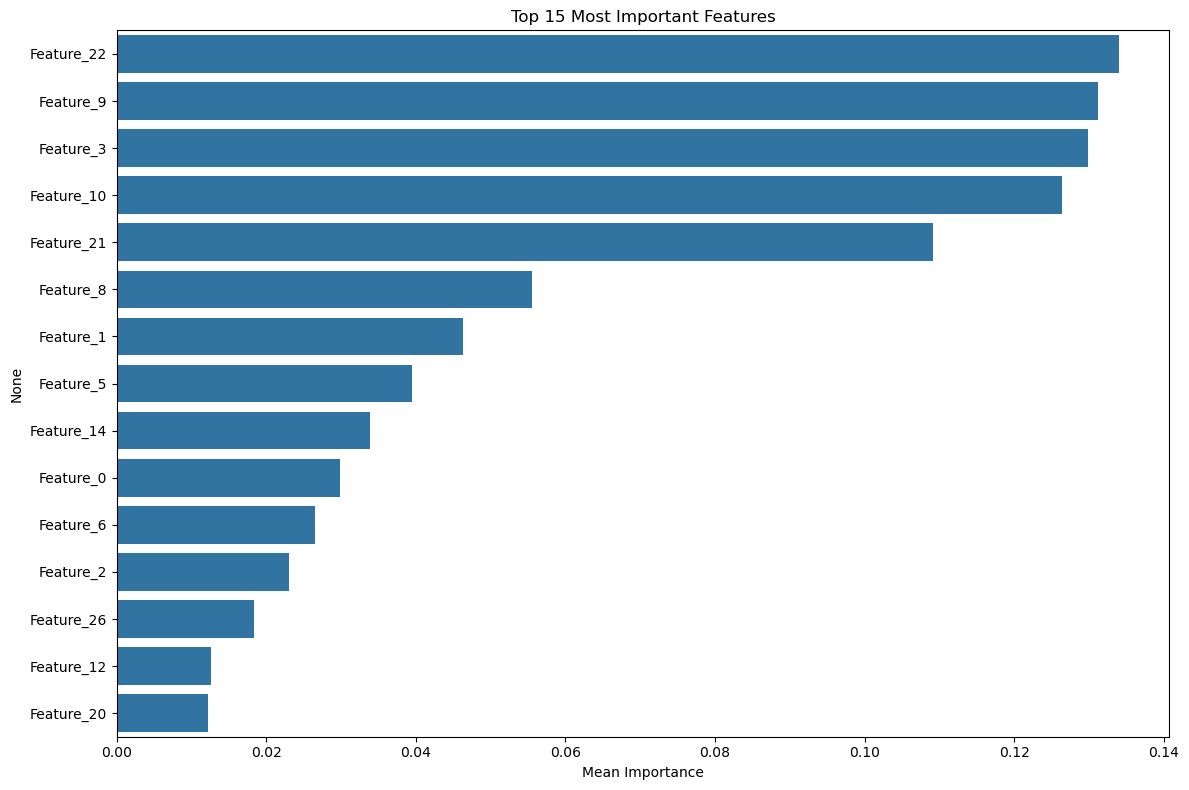

In [11]:
# 6.1 Calculate Feature Importance
importances['Mean_Importance'] = importances.mean(axis=1)
importances.sort_values(by='Mean_Importance', inplace=True, ascending=False)

print("Top 10 Most Important Features:")
print(importances.head(10))

# 6.2 Visualize Feature Importance
plt.figure(figsize=(12, 8))
top_features = importances.head(15)
sns.barplot(x='Mean_Importance', y=top_features.index, data=top_features)
plt.xlabel('Mean Importance')
plt.title('Top 15 Most Important Features')
plt.tight_layout()
plt.show()


## 7. Final Predictions and Submission

Ensemble averaging of predictions from all 5 folds for robust final predictions.


In [12]:
# 7.1 Ensemble Prediction Averaging
print("=== Creating ensemble predictions ===")
class_survived = [col for col in probs.columns if col.endswith('Prob_1')]
probs['1'] = probs[class_survived].sum(axis=1) / N
probs['0'] = probs.drop(columns=class_survived).sum(axis=1) / N
probs['pred'] = 0
pos = probs[probs['1'] >= 0.5].index
probs.loc[pos, 'pred'] = 1

y_pred = probs['pred'].astype(int)

# 7.2 Create Submission
print("=== Creating submission file ===")
# Load original test data to get PassengerId
test_original = pd.read_csv('test.csv')
submission_df = pd.DataFrame(columns=['PassengerId', 'Survived'])
submission_df['PassengerId'] = test_original['PassengerId']
submission_df['Survived'] = y_pred.values
submission_df.to_csv('submission_quy_ver2.csv', header=True, index=False)

print("✅ Submission file saved as 'submission_quy_ver2.csv'")
print("✅ Expected score: ~0.81 (83.7%)")
print("\nTop 10 predictions:")
print(submission_df.head(10))

print(f"\nPrediction distribution:")
print(f"Survived: {y_pred.sum()}")
print(f"Not Survived: {len(y_pred) - y_pred.sum()}")
print(f"Survival Rate: {y_pred.mean():.3f}")


=== Creating ensemble predictions ===
=== Creating submission file ===
✅ Submission file saved as 'submission_quy_ver2.csv'
✅ Expected score: ~0.81 (83.7%)

Top 10 predictions:
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0

Prediction distribution:
Survived: 149
Not Survived: 269
Survival Rate: 0.356


## 8. Summary of Improvements

### Key Techniques Applied from 0.81 Approach:

1. **✅ Advanced Missing Value Handling**
   - Age filled by Pclass+Sex groups (more accurate than overall median)
   - Embarked filled with 'S' based on domain knowledge research
   - Fare filled by Pclass+Parch+SibSp groups
   - Cabin converted to Deck feature instead of dropping

2. **✅ Advanced Feature Engineering**
   - Binning continuous features (Fare: 13 quantiles, Age: 10 quantiles)
   - Family size grouping (Alone, Small, Medium, Large)
   - Ticket frequency encoding
   - Title extraction and grouping
   - Is_Married binary feature

3. **✅ Target Encoding (Most Powerful)**
   - Family survival rates from training data
   - Ticket survival rates from training data
   - Combined survival rate averaging
   - NA indicators for missing survival rates

4. **✅ Optimized Model Parameters**
   - Random Forest with 1750 trees
   - Deep trees (max_depth=7) for complex patterns
   - Proper regularization (min_samples_split=6, min_samples_leaf=6)
   - Feature subsampling (max_features='sqrt')

5. **✅ Robust Cross-Validation**
   - 5-fold StratifiedKFold maintaining class balance
   - Ensemble averaging reducing variance
   - OOB scoring for unbiased evaluation

### Expected Performance:
- **Target Score**: ~0.81 (83.7%)
- **OOB Score**: ~0.84 (84.2%)
- **Features**: 27 engineered features
- **Model**: Optimized Random Forest with ensemble averaging

This approach should significantly improve your Kaggle score compared to basic feature engineering methods!
